In [7]:
from pathlib import Path
from src.data import io

In [8]:
raw_dir = Path("/home/dani/github/profecia/data/raw/profecia")
processed_base_dir = Path("/home/dani/github/profecia/data/processed")

temporal_resolution = "monthly"   # o "monthly"
output_dir = processed_base_dir / temporal_resolution
output_dir.mkdir(parents=True, exist_ok=True)

VARIABLE_NAMES = ["LAI", "SM1", "SM2", "TP", "T2M", "SSRD", "VPD"]

results = {}

## cargar LAI y construir mascaras

In [9]:
# Cargar LAI y construir máscara
lai_raw, _ = io.load_netcdf(
    base_dir=raw_dir,
    variable="LAI",
    start_year=1982,
    end_year_inclusive=2022,
    dtype="float32",
)

lai_for_mask = io.aggregate_time(
    da=lai_raw,
    variable_name="LAI",
    temporal_resolution=temporal_resolution,
)

land_mask = io.build_land_mask_from_lai(lai_for_mask, threshold=0.5)

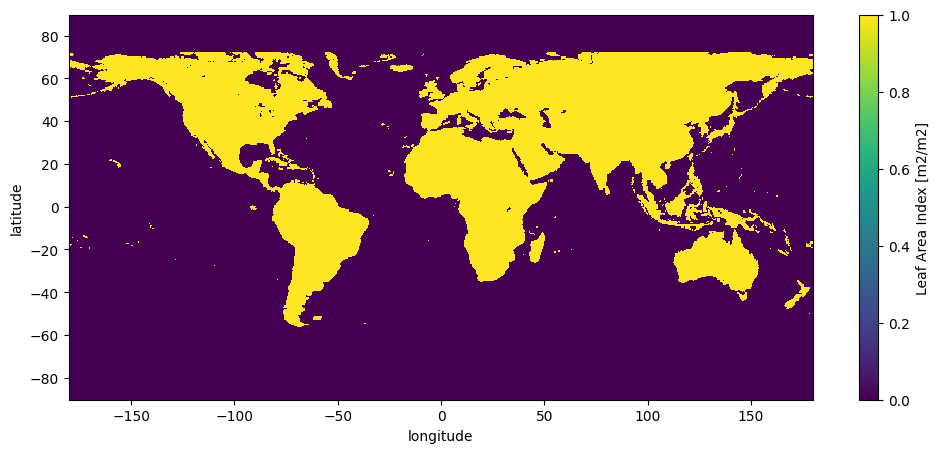

In [10]:
land_mask.astype(int).plot(figsize=(12, 5))

## guardar las variables

In [11]:
# Guardar variables
for var in VARIABLE_NAMES:
    results[var] = io.load_and_save_variable(
        raw_dir=raw_dir,
        output_dir=output_dir,
        variable=var,
        start_year=1982,
        end_year_inclusive=2022,
        dtype="float32",
        temporal_resolution=temporal_resolution,
        land_mask=land_mask,
        save_output=True,
    )

## guardar metadata global

In [12]:
# Guardar metadata.json global compatible con eda.py
io.save_processed_metadata(
    output_dir=output_dir,
    variable_results=results,
    temporal_resolution=temporal_resolution,
    start_year=1982,
    end_year_inclusive=2022,
    dtype="float32",
)

PosixPath('/home/dani/github/profecia/data/processed/monthly/metadata.json')